In [1]:
!pip install pandas numpy matplotlib bs4 nltk scikit-learn

In [2]:
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
import string
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Data/amazon.csv')
df.head()

,Text,label
0,This is the best apps acording to a bunch of ...,1
1,This is a pretty good version of the game for ...,1
2,this is a really . there are a bunch of levels...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text) # bỏ số
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\W', ' ', text) # bỏ kí tự đặc biệt
    text = BeautifulSoup(text, "html.parser").get_text()
    return " ".join(text.split())

In [5]:
df["cleaned_text"] = [clean_text(rw) for rw in df["Text"]]

In [6]:
def tokenize(text):
    return [word for word in text.split(' ')]

In [7]:
df["tokenized"] = [tokenize(rw) for rw in df["cleaned_text"]]

In [8]:
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

def remove_stopwords(words):
    stop_words = set(stopwords.words("english"))
    return [word for word in words if word not in stop_words]

[nltk_data] Downloading package stopwords to C:\Users\ASUS
[nltk_data]     ZENBOOK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
df["tokenized"] = [remove_stopwords(words) for words in df["tokenized"]]

In [10]:
df.head()

,Text,label,cleaned_text,tokenized
0,This is the best apps acording to a bunch of ...,1,this is the best apps acording to a bunch of p...,"[best, apps, acording, bunch, people, agree, b..."
1,This is a pretty good version of the game for ...,1,this is a pretty good version of the game for ...,"[pretty, good, version, game, free, lots, diff..."
2,this is a really . there are a bunch of levels...,1,this is a really there are a bunch of levels a...,"[really, bunch, levels, find, golden, eggs, su..."
3,"This is a silly game and can be frustrating, b...",1,this is a silly game and can be frustrating bu...,"[silly, game, frustrating, lots, fun, definite..."
4,This is a terrific game on any pad. Hrs of fun...,1,this is a terrific game on any pad hrs of fun ...,"[terrific, game, pad, hrs, fun, grandkids, lov..."


In [11]:
class BagOfWord:
    def __init__(self):
        self.vocab = []
        self.word_to_index = {}

    def fit(self, documents):
        seen = set()
        for doc in documents:
            for word in doc:
                if word not in seen:
                    seen.add(word)
                    self.word_to_index[word] = len(self.vocab)
                    self.vocab.append(word)

    def transform(self, documents):
        vectors = []
        for doc in documents:
            vector = [0] * len(self.vocab)
            for word in doc:
                idx = self.word_to_index.get(word)
                if idx is not None:
                    vector[idx] += 1
            vectors.append(vector)
        return vectors

    def fit_transform(self, documents):
        self.fit(documents)
        return self.transform(documents)

In [12]:
bow = BagOfWord()
vectors = np.array(bow.fit_transform(df["tokenized"]))

In [13]:
classes = np.array(df[["label"]]).reshape(-1)

In [14]:
print("=== BAG OF WORDS ===")
print(f"Vocabulary: {len(bow.vocab)} words")
print("First 10 featured vector:")
for i in range(10):
    print(vectors[i][:10], "...")

=== BAG OF WORDS ===
Vocabulary: 22973 words
First 10 featured vector:
[1 1 1 1 1 1 1 1 2 1] ...
[0 0 0 0 0 0 0 0 0 0] ...
[0 0 0 1 0 0 0 1 0 0] ...
[0 0 0 0 0 0 0 0 0 0] ...
[0 0 0 0 0 0 0 0 0 0] ...
[0 0 0 0 0 0 0 0 0 0] ...
[0 0 0 0 0 0 0 0 0 0] ...
[0 0 0 0 0 0 0 0 0 0] ...
[0 0 0 0 0 0 0 0 0 0] ...
[1 0 0 0 0 0 0 0 0 0] ...


In [15]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [16]:
Trainvecs_count, Testvecs_count, Trainclss_count, Testclss_count = train_test_split(vectors, classes, test_size=0.2, random_state=42)
print("Shape of Trainvecs_count:", Trainvecs_count.shape)
print("Shape of Testvecs_count:", Testvecs_count.shape)

Shape of Trainvecs_count: (15996, 22973)
Shape of Testvecs_count: (4000, 22973)


In [17]:
class MultinomialNB_():
  def __init__(self, alpha=1):
    self.alpha = alpha
    self.priors = {}
    self.likelihoods = {}
    self.classes_ = None
    self.vocab_size = 0

  def fit(self, X, y):
    self.classes_ = np.unique(y)
    self.vocab_size = X.shape[1] # Number of unique words in the vocabulary

    # Calculate prior probabilities P(C)
    num_samples = X.shape[0]
    for c in self.classes_:
      num_samples_in_class = np.sum(y == c)
      self.priors[c] = np.log(num_samples_in_class / num_samples)

    # Calculate conditional probabilities P(word|C)
    for c in self.classes_:
      # Filter data for current class
      X_c = X[y == c]

      # Sum word counts for each word in this class
      # np.sum(X_c, axis=0) gives total count of each word across all documents in class c
      word_counts_in_class = np.sum(X_c, axis=0)

      # Total number of words in class c (sum of all word counts in documents of class c)
      total_words_in_class = np.sum(word_counts_in_class)

      # Apply Laplace smoothing (alpha) for likelihood calculation
      # P(word_j|C) = (count(word_j in C) + alpha) / (sum(count(word_k in C) for all k) + alpha * vocab_size)
      self.likelihoods[c] = np.log((word_counts_in_class + self.alpha) / (total_words_in_class + self.alpha * self.vocab_size))
  def predict(self, X):
    predictions = []
    for x in X:
      # Calculate posterior probability for each class
      posteriors = []
      for c in self.classes_:
        # log(P(C|x)) = log(P(C)) + sum(log(P(word_i|C))) for all words in x
        # Here, x represents the counts of words. We multiply likelihood by word count.
        # This is essentially sum(count_of_word_i_in_x * log(P(word_i|C))) for all words
        # However, it's more accurate to sum log(likelihood) for each occurrence of a word.
        # So, we take the dot product of word counts (x) and log likelihoods.
        class_posterior = self.priors[c] + np.dot(x, self.likelihoods[c])
        posteriors.append(class_posterior)
      predictions.append(self.classes_[np.argmax(posteriors)])
    return np.array(predictions)


In [18]:
# Instantiate and fit the custom MultinomialNB model
custom_mnb = MultinomialNB_()
custom_mnb.fit(Trainvecs_count, Trainclss_count)

In [19]:
print("Custom Multinomial Naive Bayes model trained successfully.")
print("Priors (log-probabilities):", custom_mnb.priors)
# Display a sample of likelihoods for class 0 (ham) and class 1 (spam)
print("Sample Likelihoods for Class 0 (first 5 words):", custom_mnb.likelihoods[0][:5])
print("Sample Likelihoods for Class 1 (first 5 words):", custom_mnb.likelihoods[1][:5])

Custom Multinomial Naive Bayes model trained successfully.
Priors (log-probabilities): {np.int64(0): np.float64(-1.4405005156607402), np.int64(1): np.float64(-0.2702472164424707)}
Sample Likelihoods for Class 0 (first 5 words): [ -7.66564799  -5.80935    -11.35452744  -8.78957809  -6.36409486]
Sample Likelihoods for Class 1 (first 5 words): [ -5.66227712  -5.76791614 -12.34438571  -8.76086677  -6.14387654]


In [20]:

# Make predictions on the test set
pred_test_custom = custom_mnb.predict(Testvecs_count)

print("First 10 predictions from custom MultinomialNB:", pred_test_custom[:10])
print("Corresponding true labels:", Testclss_count[:10])

First 10 predictions from custom MultinomialNB: [0 1 0 1 1 1 1 1 1 0]
Corresponding true labels: [0 1 0 1 1 1 0 1 1 0]


In [21]:
from sklearn.metrics import precision_score, recall_score, classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay

--- Custom Multinomial Naive Bayes Model Performance ---
Precision: 0.9061093247588424
Recall: 0.9324950363997353
F1 Score: 0.9191128506196999
Accuracy: 0.876


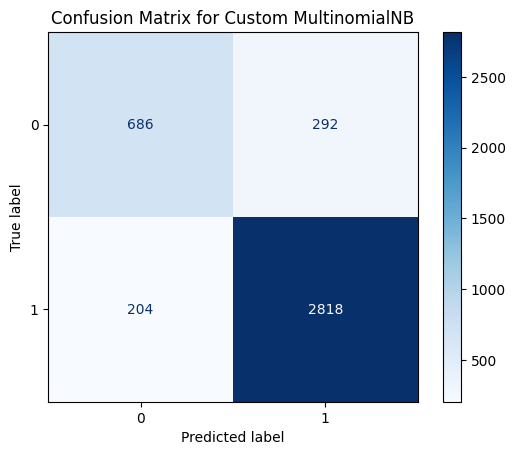

In [22]:
prec_custom = metrics.precision_score(Testclss_count, pred_test_custom)
recal_custom = metrics.recall_score(Testclss_count, pred_test_custom)
f1_s_custom = metrics.f1_score(Testclss_count, pred_test_custom)
accuracy_custom = metrics.accuracy_score(Testclss_count, pred_test_custom)

print("--- Custom Multinomial Naive Bayes Model Performance ---")
print("Precision: {}".format(prec_custom))
print("Recall: {}".format(recal_custom))
print("F1 Score: {}".format(f1_s_custom))
print("Accuracy: {}".format(accuracy_custom))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(Testclss_count, pred_test_custom, cmap="Blues")
plt.title("Confusion Matrix for Custom MultinomialNB")
plt.show()

In [23]:
class BernoulliNB_():
  def __init__(self, alpha=1):
    self.alpha = alpha
    self.priors = {}
    self.likelihoods_word_present = {}
    self.likelihoods_word_absent = {}
    self.classes_ = None
    self.vocab_size = 0

  def fit(self, X, y):
    self.classes_ = np.unique(y)
    self.vocab_size = X.shape[1] # Number of unique words in the vocabulary

    # Binarize X: any count > 0 becomes 1, 0 remains 0
    X_binarized = (X > 0).astype(int)

    # Calculate prior probabilities P(C)
    num_samples = X.shape[0]
    for c in self.classes_:
      num_samples_in_class = np.sum(y == c)
      self.priors[c] = np.log(num_samples_in_class / num_samples)

    # Calculate conditional probabilities P(word|C)
    for c in self.classes_:
      # Filter binarized data for current class
      X_c_binarized = X_binarized[y == c]
      num_docs_in_class = X_c_binarized.shape[0]

      # P(word_j=1|C) = (count of documents in C where word j appears + alpha) / (total documents in C + alpha * 2)
      word_presence_counts = np.sum(X_c_binarized, axis=0)
      self.likelihoods_word_present[c] = np.log((word_presence_counts + self.alpha) / (num_docs_in_class + self.alpha * 2))

      # P(word_j=0|C) = (count of documents in C where word j does NOT appear + alpha) / (total documents in C + alpha * 2)
      self.likelihoods_word_absent[c] = np.log(((num_docs_in_class - word_presence_counts) + self.alpha) / (num_docs_in_class + self.alpha * 2))

  def predict(self, X):
    predictions = []
    # Binarize input X for prediction, similar to how it was done in fit
    X_binarized = (X > 0).astype(int)

    for x_sample in X_binarized:
      posteriors = []
      for c in self.classes_:
        class_posterior = self.priors[c]
        for j in range(self.vocab_size):
          if x_sample[j] == 1:
            class_posterior += self.likelihoods_word_present[c][j]
          else:
            class_posterior += self.likelihoods_word_absent[c][j]
        posteriors.append(class_posterior)
      predictions.append(self.classes_[np.argmax(posteriors)])
    return np.array(predictions)


In [24]:
# Instantiate and fit the custom BernoulliNB model
custom_bnb = BernoulliNB_()
custom_bnb.fit(Trainvecs_count, Trainclss_count)

In [25]:
print("Custom Bernoulli Naive Bayes model trained successfully.")
print("Priors (log-probabilities):")
for c, prior in custom_bnb.priors.items():
    print(f"  Class {c}: {prior:.4f}")
# Display a sample of likelihoods for class 0 (ham) and class 1 (spam)
print("Sample Likelihoods for Class 0 (word present, first 5 words):", np.round(custom_bnb.likelihoods_word_present[0][:5], 4))
print("Sample Likelihoods for Class 0 (word absent, first 5 words):", np.round(custom_bnb.likelihoods_word_absent[0][:5], 4))
print("Sample Likelihoods for Class 1 (word present, first 5 words):", np.round(custom_bnb.likelihoods_word_present[1][:5], 4))
print("Sample Likelihoods for Class 1 (word absent, first 5 words):", np.round(custom_bnb.likelihoods_word_absent[1][:5], 4))

Custom Bernoulli Naive Bayes model trained successfully.
Priors (log-probabilities):
  Class 0: -1.4405
  Class 1: -0.2702
Sample Likelihoods for Class 0 (word present, first 5 words): [-4.5512 -2.802  -8.2401 -5.6752 -3.2914]
Sample Likelihoods for Class 0 (word absent, first 5 words): [-0.0106 -0.0626 -0.0003 -0.0034 -0.0379]
Sample Likelihoods for Class 1 (word present, first 5 words): [-2.7688 -2.93   -9.41   -5.8265 -3.303 ]
Sample Likelihoods for Class 1 (word absent, first 5 words): [-0.0648 -0.0549 -0.0001 -0.003  -0.0375]


In [26]:
# Make predictions on the test set
pred_test_custom_bnb = custom_bnb.predict(Testvecs_count)

print("First 10 predictions from custom BernoulliNB:", pred_test_custom_bnb[:10])
print("Corresponding true labels:", Testclss_count[:10])

First 10 predictions from custom BernoulliNB: [0 1 0 1 1 1 1 1 1 0]
Corresponding true labels: [0 1 0 1 1 1 0 1 1 0]


--- Custom Bernoulli Naive Bayes Model Performance ---
Precision: 0.8821714990746453
Recall: 0.9463931171409663
F1 Score: 0.913154533844189
Accuracy: 0.864


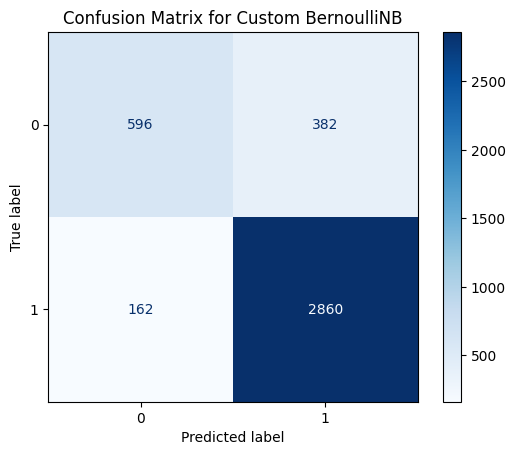

In [27]:
prec_custom_bnb = metrics.precision_score(Testclss_count, pred_test_custom_bnb)
recal_custom_bnb = metrics.recall_score(Testclss_count, pred_test_custom_bnb)
f1_s_custom_bnb = metrics.f1_score(Testclss_count, pred_test_custom_bnb)
accuracy_custom_bnb = metrics.accuracy_score(Testclss_count, pred_test_custom_bnb)

print("--- Custom Bernoulli Naive Bayes Model Performance ---")
print("Precision: {}".format(prec_custom_bnb))
print("Recall: {}".format(recal_custom_bnb))
print("F1 Score: {}".format(f1_s_custom_bnb))
print("Accuracy: {}".format(accuracy_custom_bnb))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(Testclss_count, pred_test_custom_bnb, cmap="Blues")
plt.title("Confusion Matrix for Custom BernoulliNB")
plt.show()

In [52]:
import numpy as np

class LogisticRegression_:
    def __init__(self, lr=0.01, n_iterations=1000, l2_lambda=0.0, class_weight_0=3.0, class_weight_1=1.0):
        self.lr = lr
        self.n_iterations = n_iterations
        self.l2_lambda = l2_lambda
        self.class_weight_0 = class_weight_0
        self.class_weight_1 = class_weight_1
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0.0
        y = np.array(y)

        # gán trọng số cho từng mẫu
        sample_weights = np.where(y == 0, self.class_weight_0, self.class_weight_1)

        for i in range(self.n_iterations):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(z)

            error = y_pred - y

            # nhân lỗi với trọng số từng mẫu
            weighted_error = sample_weights * error

            dw = (1 / num_samples) * np.dot(X.T, weighted_error) + (self.l2_lambda / num_samples) * self.weights
            db = (1 / num_samples) * np.sum(weighted_error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if i % (self.n_iterations / 10) == 0:
                eps = 1e-8
                cost = -np.mean(
                    sample_weights * (
                        y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps)
                    )
                )
                print(f"Iter {i}: cost = {cost:.6f}")

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return np.array([1 if p >= threshold else 0 for p in probs])

In [ ]:
# Instantiate and fit the custom Logistic Regression model again to ensure the predict method is included
custom_lr = LogisticRegression_(lr=0.05, n_iterations=100, l2_lambda=0.1, class_weight_0=2, class_weight_1=1.0)
custom_lr.fit(Trainvecs_count, Trainclss_count)

Iter 0: cost = 0.857291
Iter 20: cost = 0.844575
Iter 40: cost = 0.833702
Iter 60: cost = 0.824282
Iter 80: cost = 0.816008
Iter 100: cost = 0.808645
Iter 120: cost = 0.802008


In [ ]:

# Make predictions on the test set using the custom model
pred_test_custom_lr = custom_lr.predict(Testvecs_count)

print("First 10 predictions from custom Logistic Regression:", pred_test_custom_lr[:10])
print("Corresponding true labels:", Testclss_count[:10])

First 10 predictions from custom Logistic Regression: [0 0 0 1 1 1 0 1 1 0]
Corresponding true labels: [0 1 0 1 1 1 0 1 1 0]


--- Custom Logistic Regression Model Performance ---
Precision: 0.9248291571753986
Recall: 0.8060886829913965
F1 Score: 0.8613861386138614
Accuracy: 0.804


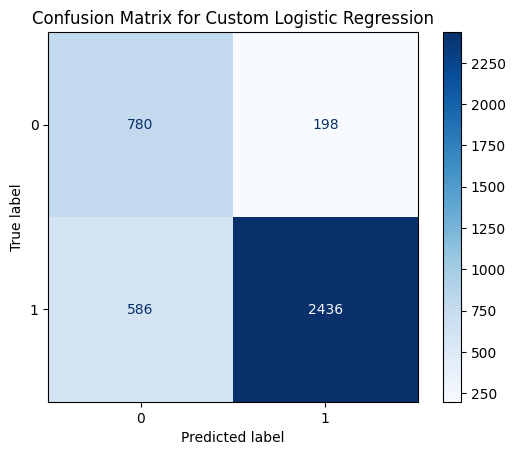

In [ ]:
prec_custom_lr = metrics.precision_score(Testclss_count, pred_test_custom_lr)
recal_custom_lr = metrics.recall_score(Testclss_count, pred_test_custom_lr)
f1_s_custom_lr = metrics.f1_score(Testclss_count, pred_test_custom_lr)
accuracy_custom_lr = metrics.accuracy_score(Testclss_count, pred_test_custom_lr)

print("--- Custom Logistic Regression Model Performance ---")
print("Precision: {}".format(prec_custom_lr))
print("Recall: {}".format(recal_custom_lr))
print("F1 Score: {}".format(f1_s_custom_lr))
print("Accuracy: {}".format(accuracy_custom_lr))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(Testclss_count, pred_test_custom_lr, cmap="Blues")
plt.title("Confusion Matrix for Custom Logistic Regression")
plt.show()